In [46]:
import sys, pathlib
CWD = pathlib.Path.cwd().resolve()
ROOT = CWD if (CWD / 'src').exists() else CWD.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

IMAGE_PATH = ROOT / 'data' / 'sample_image.jpg'
MEASURES_PATH = ROOT / 'data' / 'sample_measures.json'
HORIZON_CACHE = ROOT / 'data' / 'horizon_profile.json'

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.SolarModel import SolarModel
from src.names import SolarModelOptions, PyranoInfo, PyranoMeasure, RealPyrano, VirtualPyrano
from src.vision import compute_horizon_from_image, SINGLE_HALF_RIGHT

print('Imports OK')

Imports OK


In [31]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.SolarModel import SolarModel
from src.names import (
    SolarModelOptions,
    PyranoInfo, PyranoMeasure,
    RealPyrano, VirtualPyrano,
)
from src.vision import compute_horizon_from_image, SINGLE_HALF_RIGHT
from src.values import KD_GRID_MIN, KD_GRID_MAX, KD_GRID_STEPS

print('Imports OK')

Imports OK


## 1. Extraction du profil d'horizon depuis l'image fisheye

Si `01_test_vision.ipynb` a déjà été exécuté, le cache `horizon_profile.json`
est utilisé directement pour eviter de recharger MiDaS. Sinon, le pipeline
vision complet est lance ici (environ 30s au premier appel).

Profil d'horizon chargé depuis le cache (360 valeurs)


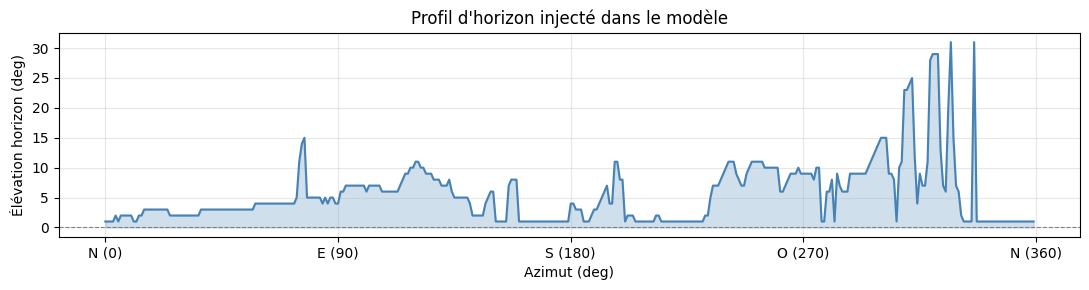

In [48]:
if HORIZON_CACHE.exists():
    with open(HORIZON_CACHE) as f:
        horizon_data = json.load(f)
    horizon_profile = np.array(horizon_data['horizon_rad'])
    print(f"Profil d'horizon chargé depuis le cache ({len(horizon_profile)} valeurs)")
elif IMAGE_PATH.exists():
    print("Calcul du profil d'horizon via MiDaS...")
    horizon_profile = compute_horizon_from_image(
        image_path = str(IMAGE_PATH),
        fov_deg = 180,
        single_half = SINGLE_HALF_RIGHT,
        azimuth_deg = 0.0,
        inclination_deg = 0.0, # CORRECTION: 0.0 pour une caméra posée à plat sur le dos
    )
    with open(HORIZON_CACHE, 'w') as f:
        json.dump({'horizon_rad': horizon_profile.tolist()}, f)
    print(f"Horizon calculé et mis en cache : {HORIZON_CACHE}")
else:
    print("ATTENTION : ni image ni cache — utilisation d'un horizon plat.")
    horizon_profile = np.zeros(360)

horizon_deg = np.rad2deg(horizon_profile)
fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(np.arange(360), horizon_deg, alpha=0.25, color='steelblue')
ax.plot(np.arange(360), horizon_deg, color='steelblue', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Azimut (deg)')
ax.set_ylabel('Élévation horizon (deg)')
ax.set_title("Profil d'horizon injecté dans le modèle")
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N (0)', 'E (90)', 'S (180)', 'O (270)', 'N (360)'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Chargement des mesures

In [51]:
with open(MEASURES_PATH) as f:
    raw = json.load(f)

meta         = raw['meta']
measurements = raw['measurements']

# Extraction des données communes
timestamps   = np.array([m['time'] for m in measurements])
origin_vals  = np.array([m['pyrano_origin_wm2'] for m in measurements], dtype=float)
dest_configs = measurements[0]['pyrano_dest']

print(f"Site      : {meta['site']}")
print(f"Periode   : {timestamps[0]}  ->  {timestamps[-1]}")
print(f"GHI range : {origin_vals.min():.1f} - {origin_vals.max():.1f} W/m²")



Site      : Paris, toit Haussmannien
Periode   : 2024-06-21 07:00:00.000  ->  2024-06-21 16:00:00.000
GHI range : 150.0 - 900.0 W/m²


## 3. Construction du SolarModel et Fitting du kd

In [52]:
# Options globales (identiques pour toutes les mesures)
options = SolarModelOptions(
    latitude = meta['latitude'],
    longitude = meta['longitude'],
    elevation_meter = meta['elevation_meter'],
    albedo = 0.2,
    use_riso = False,
)

print(f"Site : {meta['site']}")
print(f"Simulation de {len(measurements)} instants de mesure individuels...\n")

results_list = []
kd_history = []
time_history =[]

# BOUCLE TEMPS RÉEL : On traite chaque instant T séparément
for m in measurements:
    t_str = m['time']
    time_history.append(t_str.split(' ')[1][:5]) # Garde juste HH:MM pour les graphes
    
    # 1. Instanciation d'un modèle "neuf" pour cet instant T
    model = SolarModel(options)
    
    # 2. Ajout de l'Origin (GHI)
    model.set_origin(RealPyrano(
        info = PyranoInfo(azimuth_deg=0.0, inclination_deg=0.0, horizon=horizon_profile),
        measures = PyranoMeasure(timestamps=np.array([t_str]), values=np.array([m['pyrano_origin_wm2']], dtype=float))
    ))
    
    # 3. Ajout dynamique des Fits (3 capteurs)
    for fit in m['pyrano_fit']:
        model.add_fit(RealPyrano(
            info = PyranoInfo(
                azimuth_deg = float(fit['azimuth_deg']),
                inclination_deg = float(fit['inclination_deg']),
                horizon = horizon_profile
            ),
            measures = PyranoMeasure(timestamps=np.array([t_str]), values=np.array([fit['value_wm2']], dtype=float))
        ))
        
    # 4. Ajout dynamique des Cibles (Facades)
    for dest in m['pyrano_dest']:
        model.add_target(VirtualPyrano(
            info = PyranoInfo(
                azimuth_deg = float(dest['azimuth_deg']),
                inclination_deg = float(dest['inclination_deg']),
                horizon = horizon_profile
            )
        ))
        
    # 5. Fitting du kd UNIQUEMENT pour cet instant T
    model.fit_parameters()
    kd_history.append(model.kd)
    
    # 6. Projection et sauvegarde
    df_instant = model.project()
    results_list.append(df_instant)

# Concaténation de tous les instants pour l'analyse globale
df_final = pd.concat(results_list, ignore_index=True)
print("Simulation terminée avec succès !")

Site : Paris, toit Haussmannien
Simulation de 10 instants de mesure individuels...

[solver] kd optimal : 0.5253  (index médian : 52)
[solver] kd optimal : 0.4647  (index médian : 46)
[solver] kd optimal : 0.4546  (index médian : 45)
[solver] kd optimal : 0.6667  (index médian : 66)
[solver] kd optimal : 0.0001  (index médian : 0)
[solver] kd optimal : 0.0001  (index médian : 0)
[solver] kd optimal : 0.1112  (index médian : 11)
[solver] kd optimal : 0.6667  (index médian : 66)
[solver] kd optimal : 0.5051  (index médian : 50)
[solver] kd optimal : 0.8081  (index médian : 80)
Simulation terminée avec succès !


## 4 Analyse des variations du kd
​


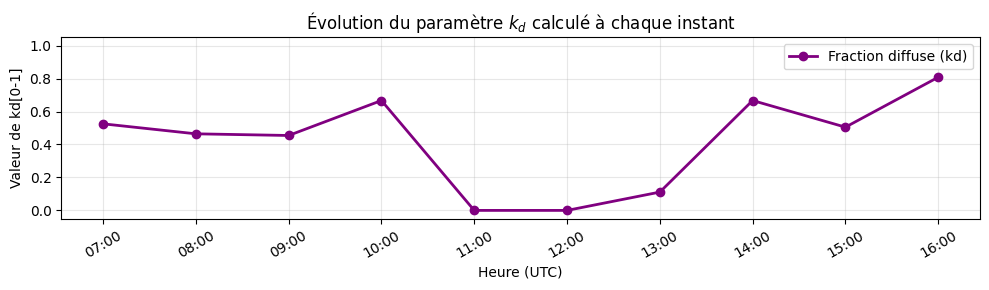

Moyenne kd sur la période : 0.420


In [53]:
x = np.arange(len(time_history))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, kd_history, marker='o', color='purple', linewidth=2, label='Fraction diffuse (kd)')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)')
ax.set_ylabel('Valeur de kd[0-1]')
ax.set_title('Évolution du paramètre $k_d$ calculé à chaque instant')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne kd sur la période : {np.mean(kd_history):.3f}")

## 5. Projection et resultats

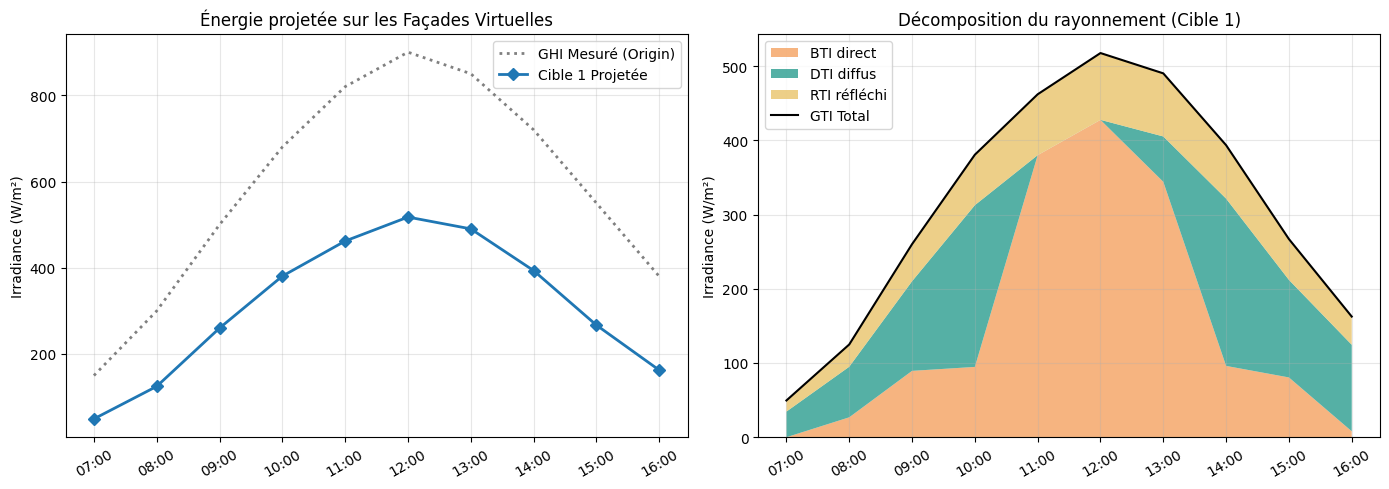

In [57]:
# Extraction des vraies valeurs origin
origin_vals = df_final['pyrano-origin'].values
dest_cols =[c for c in df_final.columns if 'dest' in c and 'value' in c]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : GHI vs GTI Projetés
ax1 = axes[0]
ax1.plot(x, origin_vals, color='gray', linestyle=':', lw=2, label='GHI Mesuré (Origin)')

colors = plt.cm.tab10.colors
for i, col in enumerate(dest_cols):
    ax1.plot(x, df_final[col].values, marker='D', color=colors[i], lw=2, label=f'Cible {i+1} Projetée')

ax1.set_xticks(x); ax1.set_xticklabels(time_history, rotation=30)
ax1.set_ylabel('Irradiance (W/m²)')
ax1.set_title('Énergie projetée sur les Façades Virtuelles')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Graphique 2 : Décomposition de la lumière pour la Cible 1
ax2 = axes[1]
bti = df_final.get('pyrano-dest-1_bti', pd.Series(np.zeros(len(x))))
dti = df_final.get('pyrano-dest-1_dti', pd.Series(np.zeros(len(x))))
rti = df_final.get('pyrano-dest-1_rti', pd.Series(np.zeros(len(x))))

ax2.stackplot(x, bti.values, dti.values, rti.values,
              labels=['BTI direct', 'DTI diffus', 'RTI réfléchi'],
              colors=['#f4a261', '#2a9d8f', '#e9c46a'], alpha=0.8)
ax2.plot(x, df_final[dest_cols[0]].values, 'k-', lw=1.5, label='GTI Total')

ax2.set_xticks(x); ax2.set_xticklabels(time_history, rotation=30)
ax2.set_ylabel('Irradiance (W/m²)')
ax2.set_title('Décomposition du rayonnement (Cible 1)')
ax2.legend(loc='upper left'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [56]:
# Export
OUTPUT = ROOT / 'data' / 'results_dynamic.csv'
df_final.to_csv(OUTPUT, index=False)
print(f'Résultats exportés : {OUTPUT}')

Résultats exportés : C:\Users\OMAR\Desktop\Solar\data\results_dynamic.csv


In [58]:
# 1. On ajoute la liste des kd calculés directement dans le DataFrame final
df_final['kd_optimal'] = kd_history

# 2. Préparation des colonnes de base
cols_show =['time', 'kd_optimal', 'pyrano-origin']
rename_dict = {
    'time': 'Heure (UTC)', 
    'kd_optimal': 'Fraction Diffuse (kd)',
    'pyrano-origin': 'GHI Mesuré (W/m²)'
}

# 3. Ajout dynamique des colonnes de Fit (Sud, Est, Ouest...)
nb_fits = len(measurements[0]['pyrano_fit'])
for i in range(nb_fits):
    col_name = f'pyrano-fit-{i+1}_value'
    az  = measurements[0]['pyrano_fit'][i]['azimuth_deg']
    inc = measurements[0]['pyrano_fit'][i]['inclination_deg']
    
    cols_show.append(col_name)
    rename_dict[col_name] = f'GTI Fit {i+1} (Az={az:.0f}°, Inc={inc:.0f}°)'

# 4. Ajout dynamique des colonnes de Destination (Les façades cibles)
nb_dests = len(measurements[0]['pyrano_dest'])
for i in range(nb_dests):
    col_name = f'pyrano-dest-{i+1}_value'
    az  = measurements[0]['pyrano_dest'][i]['azimuth_deg']
    inc = measurements[0]['pyrano_dest'][i]['inclination_deg']
    
    cols_show.append(col_name)
    rename_dict[col_name] = f'GTI Cible {i+1} (Az={az:.0f}°, Inc={inc:.0f}°)'

# 5. Affichage du magnifique tableau propre
print("📊 Tableau récapitulatif des projections par instant :")
display(df_final[cols_show].rename(columns=rename_dict).round(3))

📊 Tableau récapitulatif des projections par instant :


,Heure (UTC),Fraction Diffuse (kd),GHI Mesuré (W/m²),"GTI Fit 1 (Az=180°, Inc=45°)","GTI Fit 2 (Az=90°, Inc=60°)","GTI Fit 3 (Az=270°, Inc=60°)","GTI Cible 1 (Az=180°, Inc=90°)"
0,2024-06-21 07:00:00.000,0.525,150.0,90.0,250.0,50.0,49.508
1,2024-06-21 08:00:00.000,0.465,300.0,220.0,450.0,90.0,124.941
2,2024-06-21 09:00:00.000,0.455,500.0,450.0,600.0,130.0,260.085
3,2024-06-21 10:00:00.000,0.667,680.0,650.0,550.0,180.0,380.591
4,2024-06-21 11:00:00.000,0.000,820.0,800.0,480.0,250.0,461.989
5,2024-06-21 12:00:00.000,0.000,900.0,880.0,400.0,400.0,517.554
6,2024-06-21 13:00:00.000,0.111,850.0,820.0,280.0,500.0,490.177
7,2024-06-21 14:00:00.000,0.667,720.0,680.0,180.0,600.0,393.425
8,2024-06-21 15:00:00.000,0.505,550.0,480.0,120.0,650.0,266.943
9,2024-06-21 16:00:00.000,0.808,380.0,280.0,80.0,450.0,162.535
